In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Display Settings
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
train = pd.read_csv(r"C:\Users\prabh\Downloads\archive (2)\train.csv")
test = pd.read_csv(r"C:\Users\prabh\Downloads\archive (2)\test.csv")
stores = pd.read_csv(r"C:\Users\prabh\Downloads\archive (2)\stores.csv")
features = pd.read_csv(r"C:\Users\prabh\Downloads\archive (2)\features.csv")

In [5]:
print("Train Shape :", train.shape)
print("Test Shape :", test.shape)
print("Stores Shape :", stores.shape)
print("Features Shape :", features.shape)

Train Shape : (421570, 5)
Test Shape : (115064, 4)
Stores Shape : (45, 3)
Features Shape : (8190, 12)


In [6]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [7]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [9]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [10]:
features.head

<bound method NDFrame.head of       Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0         1  2010-02-05        42.31       2.572        NaN        NaN   
1         1  2010-02-12        38.51       2.548        NaN        NaN   
2         1  2010-02-19        39.93       2.514        NaN        NaN   
3         1  2010-02-26        46.63       2.561        NaN        NaN   
4         1  2010-03-05        46.50       2.625        NaN        NaN   
...     ...         ...          ...         ...        ...        ...   
8185     45  2013-06-28        76.05       3.639    4842.29     975.03   
8186     45  2013-07-05        77.50       3.614    9090.48    2268.58   
8187     45  2013-07-12        79.37       3.614    3789.94    1827.31   
8188     45  2013-07-19        82.84       3.737    2961.49    1047.07   
8189     45  2013-07-26        76.06       3.804     212.02     851.73   

      MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0   

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [12]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [13]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [14]:
train.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [15]:
stores.isnull().sum()

Store    0
Type     0
Size     0
dtype: int64

In [16]:
features.isnull().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [17]:
train_store = pd.merge(train, stores, on="Store", how="left")

In [18]:
data = pd.merge(train_store, features, on=["Store", "Date", "IsHoliday"], how="left")

In [19]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [20]:
print("Merged Dataset Shape:", data.shape)

Merged Dataset Shape: (421570, 16)


In [21]:
data.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

In [22]:
data.fillna(data.median(numeric_only=True), inplace=True)

In [23]:
data.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
dtype: int64

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     421570 non-null  float64
 10  MarkDown2     421570 non-null  float64
 11  MarkDown3     421570 non-null  float64
 12  MarkDown4     421570 non-null  float64
 13  MarkDown5     421570 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [25]:
data["Date"] = pd.to_datetime(data["Date"])

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     421570 non-null  float64       
 10  MarkDown2     421570 non-null  float64       
 11  MarkDown3     421570 non-null  float64       
 12  MarkDown4     421570 non-null  float64       
 13  MarkDown5     421570 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

In [27]:
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Week"] = data["Date"].dt.isocalendar().week
data["Day"] = data["Date"].dt.day

In [28]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,5347.45,192.0,24.6,1481.31,3359.45,211.096358,8.106,2010,2,5,5
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,5347.45,192.0,24.6,1481.31,3359.45,211.242170,8.106,2010,2,6,12
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,5347.45,192.0,24.6,1481.31,3359.45,211.289143,8.106,2010,2,7,19
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,5347.45,192.0,24.6,1481.31,3359.45,211.319643,8.106,2010,2,8,26
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,5347.45,192.0,24.6,1481.31,3359.45,211.350143,8.106,2010,3,9,5


In [29]:
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


In [30]:
data.drop_duplicates(inplace=True)

In [31]:
data.describe()

,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Day
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.0,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,136727.915739,60.090059,3.361027,6026.195471,1021.307467,484.687953,2090.196076,3815.475623,171.201947,7.960289,2010.968591,6.449510,25.826762,15.673131
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,2010.000000,1.000000,1.0,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,132.022667,6.891000,2010.000000,4.000000,14.0,8.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,2011.000000,6.000000,26.0,16.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.280000,3.738000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,212.416993,8.572000,2012.000000,9.000000,38.0,23.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,2012.000000,12.000000,52.0,31.000000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,5039.770624,5060.726828,5527.479863,3669.249108,3625.326240,39.159276,1.863296,0.796876,3.243217,14.151887,8.753549


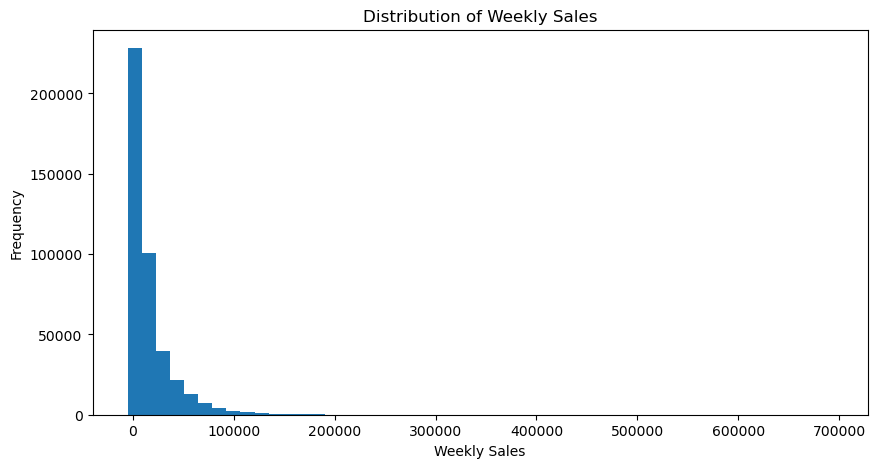

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(data["Weekly_Sales"], bins=50)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

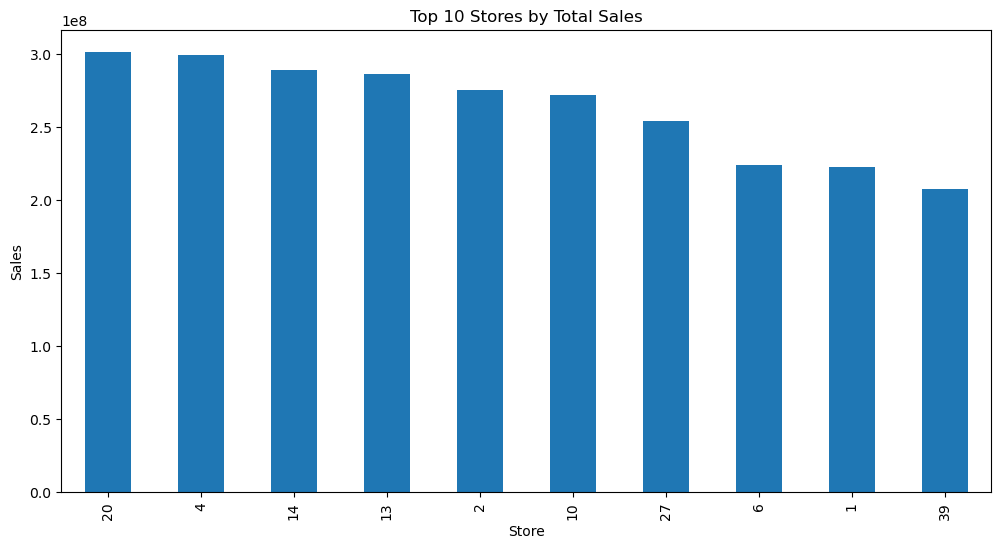

In [33]:
store_sales = data.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
store_sales.head(10).plot(kind="bar")
plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()

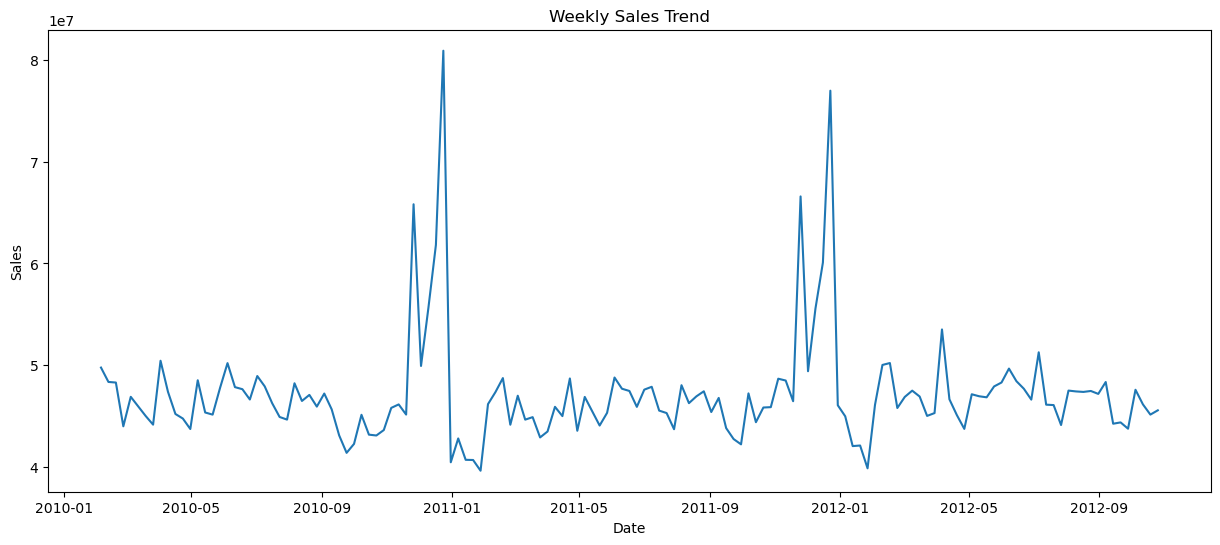

In [34]:
sales_trend = data.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(15,6))
plt.plot(sales_trend)
plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

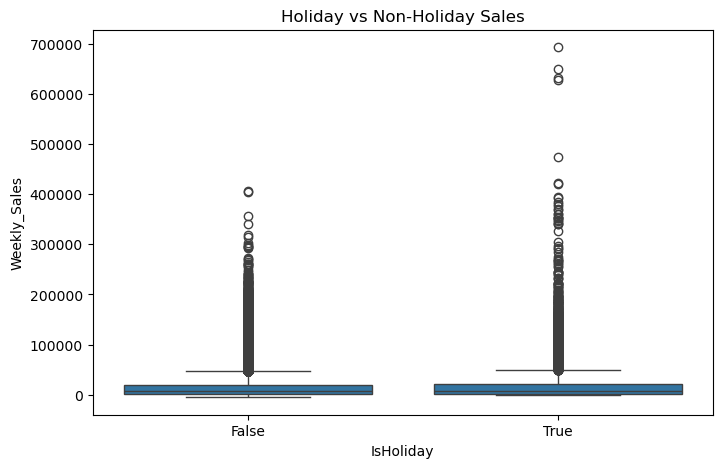

In [35]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=data)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

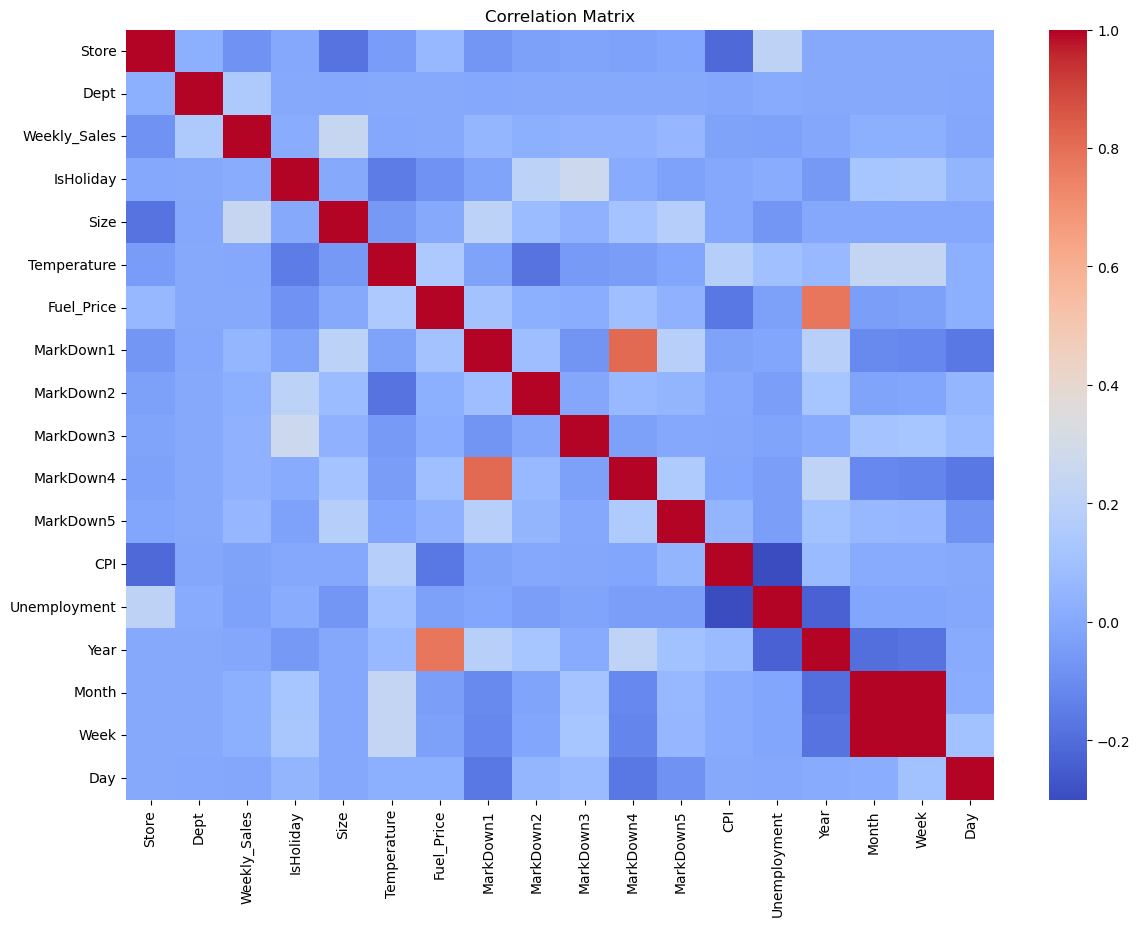

In [36]:
plt.figure(figsize=(14,10))

sns.heatmap(data.corr(numeric_only=True),
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [37]:
data = data.sort_values("Date")

In [38]:
data.reset_index(drop=True, inplace=True)

In [39]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,5347.45,192.0,24.6,1481.31,3359.45,211.096358,8.106,2010,2,5,5
1,29,5,2010-02-05,15552.08,False,B,93638,24.36,2.788,5347.45,192.0,24.6,1481.31,3359.45,131.527903,10.064,2010,2,5,5
2,29,6,2010-02-05,3200.22,False,B,93638,24.36,2.788,5347.45,192.0,24.6,1481.31,3359.45,131.527903,10.064,2010,2,5,5
3,29,7,2010-02-05,10820.05,False,B,93638,24.36,2.788,5347.45,192.0,24.6,1481.31,3359.45,131.527903,10.064,2010,2,5,5
4,29,8,2010-02-05,20055.64,False,B,93638,24.36,2.788,5347.45,192.0,24.6,1481.31,3359.45,131.527903,10.064,2010,2,5,5


In [40]:
sales_data = data[["Date", "Weekly_Sales"]]

In [41]:
sales_data.head()

,Date,Weekly_Sales
0,2010-02-05,24924.50
1,2010-02-05,15552.08
2,2010-02-05,3200.22
3,2010-02-05,10820.05
4,2010-02-05,20055.64


In [43]:
sales_data = sales_data.groupby("Date")["Weekly_Sales"].sum().reset_index()
sales_data.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [44]:
print(sales_data.shape)

(143, 2)


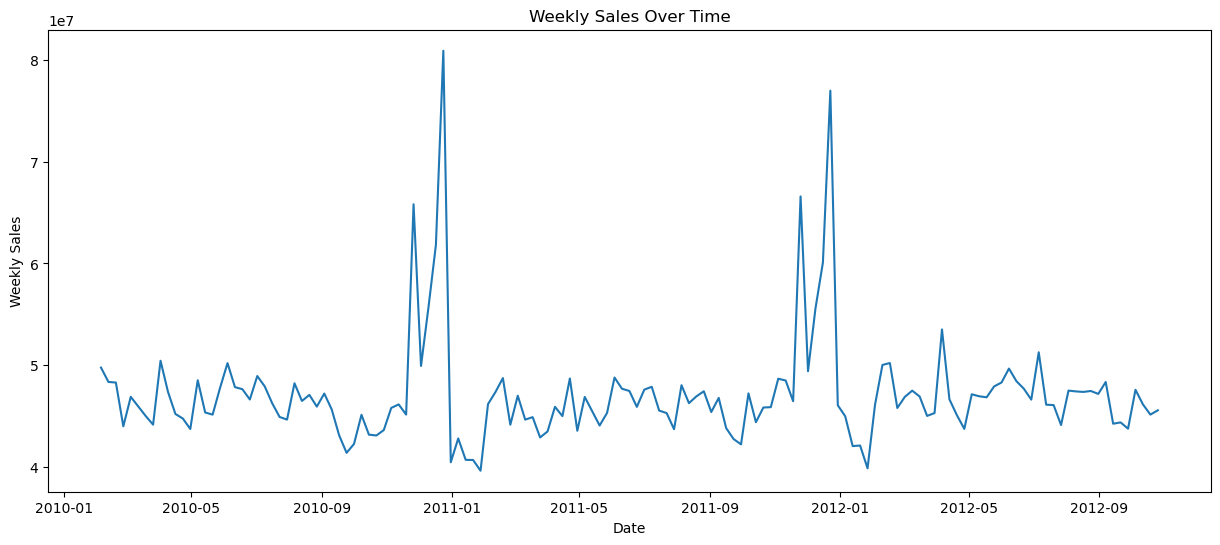

In [45]:
plt.figure(figsize=(15,6))

plt.plot(sales_data["Date"], sales_data["Weekly_Sales"])

plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.show()

In [46]:
from sklearn.preprocessing import MinMaxScaler

In [47]:
scaler = MinMaxScaler(feature_range=(0,1))

In [48]:
scaled_data = scaler.fit_transform(sales_data[["Weekly_Sales"]])

In [49]:
scaled_data[:5]

array([[0.24559651],
       [0.21138385],
       [0.20993982],
       [0.10569932],
       [0.17593376]])

In [50]:
sequence_length = 10

X = []
y = []

In [51]:
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

In [52]:
X = np.array(X)
y = np.array(y)

In [53]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (133, 10)
y Shape: (133,)


In [54]:
X = X.reshape((X.shape[0], X.shape[1], 1))

In [55]:
print(X.shape)

(133, 10, 1)


In [56]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [57]:
print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (106, 10, 1)
Testing Samples: (27, 10, 1)


In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [59]:
model = Sequential()

# First LSTM Layer
model.add(LSTM(units=64,
               return_sequences=True,
               input_shape=(X_train.shape[1], 1)))

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(units=32))

model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1))

In [60]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [62]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - loss: 0.0379 - val_loss: 0.0019
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0249 - val_loss: 0.0034
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0247 - val_loss: 0.0021
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0234 - val_loss: 0.0019
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0243 - val_loss: 0.0020
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0232 - val_loss: 0.0018
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0242 - val_loss: 0.0018
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0233 - val_loss: 0.0019
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0224 - val_loss: 0.0021
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0225 - val_loss: 0.0018
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0226 - val_loss: 0.0018
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0227 - val_loss: 0.0019

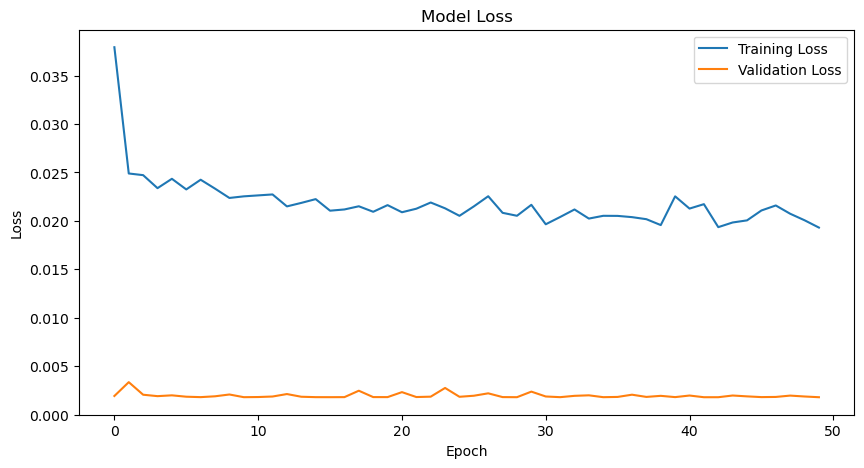

In [63]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [64]:
predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step


In [65]:
predictions[:5]

array([[0.17894298],
       [0.16770925],
       [0.16501383],
       [0.1679233 ],
       [0.17229877]], dtype=float32)

In [66]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [68]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)

print("RMSE:", rmse)
print("MAE :", mae)

RMSE: 1751696.1024858805
MAE : 1420748.7800000012


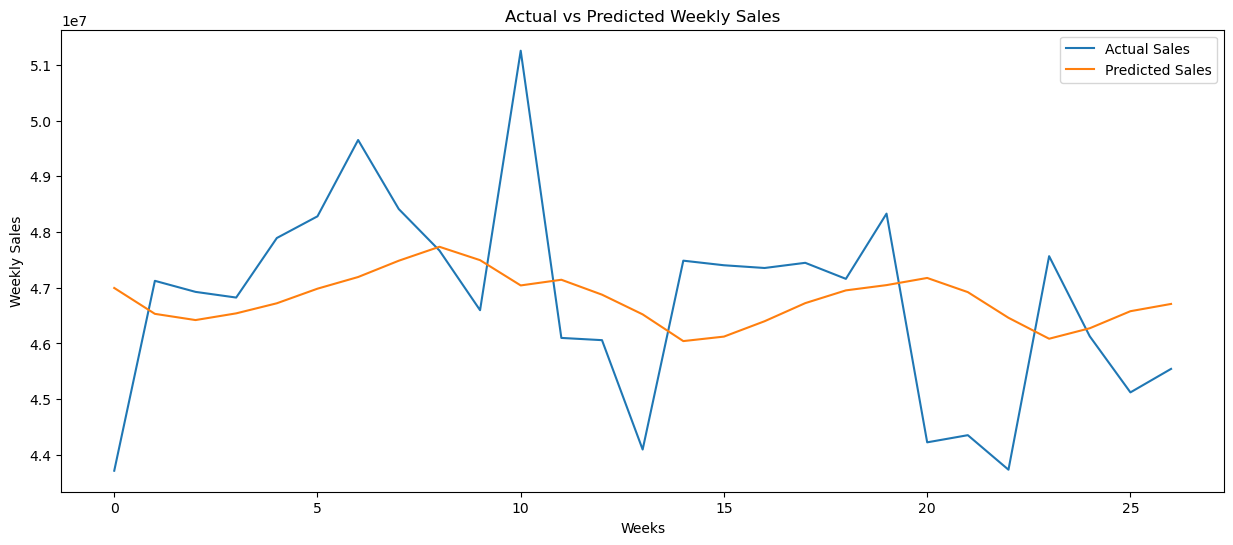

In [69]:
plt.figure(figsize=(15,6))

plt.plot(y_test_actual, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Weeks")
plt.ylabel("Weekly Sales")

plt.legend()

plt.show()

In [70]:
model.save("lstm_sales_forecasting.keras")

In [71]:
last_sequence = scaled_data[-sequence_length:]
last_sequence = last_sequence.reshape(1, sequence_length, 1)

future_predictions = []

for i in range(30):
    pred = model.predict(last_sequence, verbose=0)
    future_predictions.append(pred[0,0])

    last_sequence = np.append(last_sequence[:,1:,:],
                              [[[pred[0,0]]]],
                              axis=1)

In [72]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

In [73]:
forecast_df = pd.DataFrame({
    "Week": range(1, 31),
    "Predicted Weekly Sales": future_predictions.flatten()
})

forecast_df

,Week,Predicted Weekly Sales
0,1,46810020.0
1,2,47026804.0
2,3,47232500.0
3,4,47415900.0
4,5,47410672.0
5,6,47358136.0
6,7,47243308.0
7,8,47201880.0
8,9,47086564.0
9,10,46942596.0


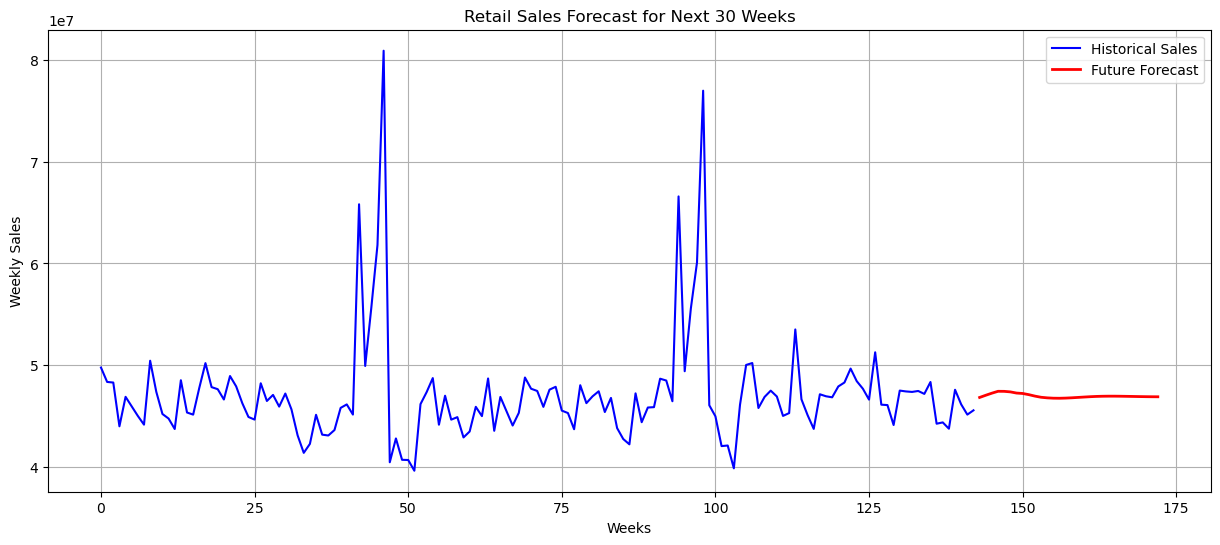

In [74]:
plt.figure(figsize=(15,6))

plt.plot(
    sales_data["Weekly_Sales"].values,
    label="Historical Sales",
    color="blue"
)

future_x = range(
    len(sales_data),
    len(sales_data) + 30
)

plt.plot(
    future_x,
    future_predictions,
    label="Future Forecast",
    color="red",
    linewidth=2
)

plt.title("Retail Sales Forecast for Next 30 Weeks")
plt.xlabel("Weeks")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)

plt.show()

In [75]:
forecast_df.to_csv("future_sales_forecast.csv", index=False)

print("Future forecast saved successfully!")

Future forecast saved successfully!
